# 00 - Exploratory Data Analysis (EDA) for Churn Prediction
This notebook is the **first step** of the project.

Goals:
- Inspect raw event logs for train and test datasets
- Understand users, time coverage, churn label definition
- Check missing values, basic distributions, and potential leakage
- Produce an initial profiling report to guide feature engineering


In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set(style='whitegrid')
except ImportError:
    sns = None

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)


In [2]:
# Standalone paths for EDA
TRAIN_PARQUET = 'data/train.parquet'
TEST_PARQUET = 'data/test.parquet'

TRAIN_PARQUET, TEST_PARQUET

('data/train.parquet', 'data/test.parquet')

In [3]:
%%time
train_df = pd.read_parquet(TRAIN_PARQUET)
test_df = pd.read_parquet(TEST_PARQUET)

# Ensure datetime types are datedatetime
train_df['time'] = pd.to_datetime(train_df['time'])
train_df['registration'] = pd.to_datetime(train_df['registration'])

test_df['time'] = pd.to_datetime(test_df['time'])
test_df['registration'] = pd.to_datetime(test_df['registration'])

print(f'Train: {len(train_df):,} events, {train_df["userId"].nunique():,} users')
print(f'Test : {len(test_df):,} events, {test_df["userId"].nunique():,} users')

Train: 17,499,636 events, 19,140 users
Test : 4,393,179 events, 2,904 users
CPU times: user 9.65 s, sys: 8.37 s, total: 18 s
Wall time: 32.8 s


In [5]:
# Header and dtypes of train
display(train_df.head())
train_df.dtypes

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
0,200,M,Shlok,paid,Johnson,1749042,1538352001000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",278,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,524.32934,Ich mache einen Spiegel - Dream Part 4,Popol Vuh,2018-10-01 00:00:01,2018-08-08 13:22:21
992,200,M,Shlok,paid,Johnson,1749042,1538352525000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",279,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,178.02404,Monster (Album Version),Skillet,2018-10-01 00:08:45,2018-08-08 13:22:21
1360,200,M,Shlok,paid,Johnson,1749042,1538352703000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",280,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,232.61995,Seven Nation Army,The White Stripes,2018-10-01 00:11:43,2018-08-08 13:22:21
1825,200,M,Shlok,paid,Johnson,1749042,1538352935000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",281,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,265.50812,Under The Bridge (Album Version),Red Hot Chili Peppers,2018-10-01 00:15:35,2018-08-08 13:22:21
2366,200,M,Shlok,paid,Johnson,1749042,1538353200000,Logged In,NextSong,22683,"Dallas-Fort Worth-Arlington, TX",282,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,471.69261,Circlesong 6,Bobby McFerrin,2018-10-01 00:20:00,2018-08-08 13:22:21


status                    int64
gender                   object
firstName                object
level                    object
lastName                 object
userId                   object
ts                        int64
auth                     object
page                     object
sessionId                 int64
location                 object
itemInSession             int64
userAgent                object
method                   object
length                  float64
song                     object
artist                   object
time             datetime64[us]
registration     datetime64[us]
dtype: object

In [6]:
# Header and dtypes of test
display(test_df.head())
test_df.dtypes

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
7,200,M,Jonathan,free,Martin,1465194,1538352006000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",29,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,250.82730,Mockingbird,Eminem,2018-10-01 00:00:06,2018-09-27 17:29:36
54,200,M,Jonathan,free,Martin,1465194,1538352028000,Logged In,Roll Advert,22483,"New York-Newark-Jersey City, NY-NJ-PA",30,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",GET,NaN,None,None,2018-10-01 00:00:28,2018-09-27 17:29:36
477,200,M,Jonathan,free,Martin,1465194,1538352256000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",31,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,355.78730,Thank You (Precious Memories Album Version),Ray Boltz,2018-10-01 00:04:16,2018-09-27 17:29:36
1170,200,M,Jonathan,free,Martin,1465194,1538352611000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",32,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,191.68608,Mathletics,Foals,2018-10-01 00:10:11,2018-09-27 17:29:36
1552,200,M,Jonathan,free,Martin,1465194,1538352802000,Logged In,NextSong,22483,"New York-Newark-Jersey City, NY-NJ-PA",33,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,275.25179,Proceed,The Roots,2018-10-01 00:13:22,2018-09-27 17:29:36


status                    int64
gender                   object
firstName                object
level                    object
lastName                 object
userId                   object
ts                        int64
auth                     object
page                     object
sessionId                 int64
location                 object
itemInSession             int64
userAgent                object
method                   object
length                  float64
song                     object
artist                   object
time             datetime64[us]
registration     datetime64[us]
dtype: object

In [7]:
# Time coverage and event volume
print('Train time range:')
print('  min:', train_df['time'].min())
print('  max:', train_df['time'].max())

print('\nTest time range:')
print('  min:', test_df['time'].min())
print('  max:', test_df['time'].max())

Train time range:
  min: 2018-10-01 00:00:01
  max: 2018-11-20 00:00:00

Test time range:
  min: 2018-10-01 00:00:06
  max: 2018-11-20 00:00:00


In [8]:
# Events per day in train
events_per_day = (
    train_df
    .assign(day=train_df['time'].dt.date)
    .groupby('day')['userId']
    .count()
    .rename('n_events')
    .reset_index()
)
events_per_day.head()

,day,n_events
0,2018-10-01,365478
1,2018-10-02,405387
2,2018-10-03,405160
3,2018-10-04,436489
4,2018-10-05,413261


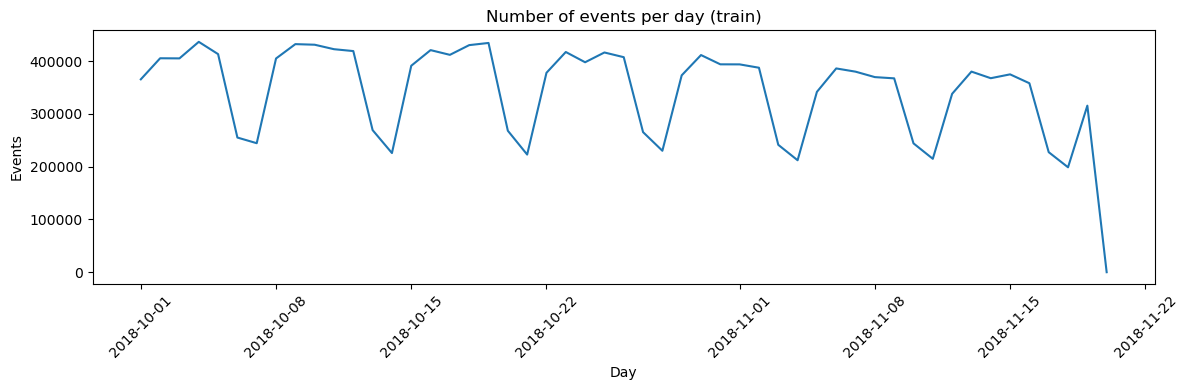

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(events_per_day['day'], events_per_day['n_events'])
plt.title('Number of events per day (train)')
plt.xlabel('Day')
plt.ylabel('Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Churn label inspection on a user level
churn_events = train_df[train_df['page'] == 'Cancellation Confirmation']

print(f'Rows with Cancellation Confirmation: {len(churn_events):,}')
print(f'Unique churned users: {churn_events["userId"].nunique():,}')

n_users = train_df['userId'].nunique()
churn_rate = churn_events['userId'].nunique() / n_users
print(f'Approx user-level churn rate (whole train period): {churn_rate:.2%}')

Rows with Cancellation Confirmation: 4,271
Unique churned users: 4,271
Approx user-level churn rate (whole train period): 22.31%


In [11]:
# Churned users per day
churn_per_day = (
    churn_events
    .assign(day=churn_events['time'].dt.date)
    .groupby('day')['userId']
    .nunique()
    .rename('n_churned_users')
    .reset_index()
)
churn_per_day.head()

,day,n_churned_users
0,2018-10-01,117
1,2018-10-02,129
2,2018-10-03,129
3,2018-10-04,126
4,2018-10-05,115


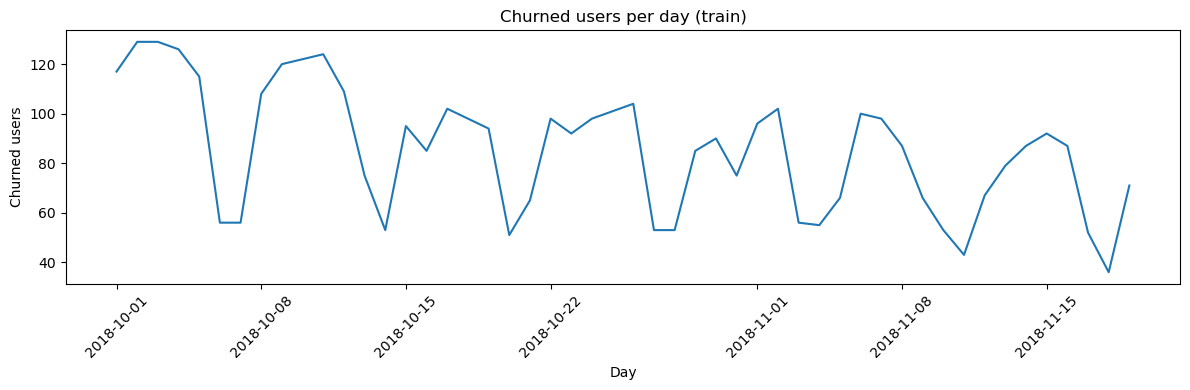

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(churn_per_day['day'], churn_per_day['n_churned_users'])
plt.title('Churned users per day (train)')
plt.xlabel('Day')
plt.ylabel('Churned users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Missing values & basic stats
missing_ratio = train_df.isna().mean().sort_values(ascending=False)
missing_ratio.head(20)

artist           0.18333
song             0.18333
length           0.18333
status           0.00000
location         0.00000
time             0.00000
method           0.00000
userAgent        0.00000
itemInSession    0.00000
sessionId        0.00000
gender           0.00000
page             0.00000
auth             0.00000
ts               0.00000
userId           0.00000
lastName         0.00000
level            0.00000
firstName        0.00000
registration     0.00000
dtype: float64

In [14]:
train_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,status,ts,sessionId,itemInSession,length,time,registration
count,1.749964e+07,1.749964e+07,1.749964e+07,1.749964e+07,1.429143e+07,17499636,17499636
mean,2.091387e+02,1.540428e+12,8.480294e+04,1.055937e+02,2.487135e+02,2018-10-25 00:47:01.161927,2018-08-25 04:40:21.543066
min,2.000000e+02,1.538352e+12,1.000000e+00,0.000000e+00,5.220000e-01,2018-10-01 00:00:01,2017-10-14 22:05:25
1%,2.000000e+02,1.538403e+12,1.616000e+03,1.000000e+00,8.097914e+01,2018-10-01 14:04:11,2018-04-03 01:23:53
5%,2.000000e+02,1.538551e+12,5.977000e+03,4.000000e+00,1.382657e+02,2018-10-03 07:14:28,2018-06-13 05:16:49
25%,2.000000e+02,1.539340e+12,2.515900e+04,2.600000e+01,1.998885e+02,2018-10-12 10:33:57.750000,2018-08-10 21:14:59
50%,2.000000e+02,1.540397e+12,7.903800e+04,6.600000e+01,2.340828e+02,2018-10-24 15:58:54,2018-09-05 18:35:50
75%,2.000000e+02,1.541500e+12,1.383680e+05,1.440000e+02,2.768714e+02,2018-11-06 10:25:35,2018-09-20 17:24:57
95%,3.070000e+02,1.542386e+12,1.871130e+05,3.410000e+02,4.040355e+02,2018-11-16 16:25:50.250000,2018-09-29 08:06:52
99%,3.070000e+02,1.542633e+12,1.998050e+05,5.470000e+02,5.871016e+02,2018-11-19 13:08:54.650000,2018-09-30 21:43:40


In [15]:
# Main categorical distributions
train_df['page'].value_counts().head(20)

page
NextSong                     14291433
Thumbs Up                      789391
Home                           645259
Add to Playlist                409606
Roll Advert                    284837
Add Friend                     262147
Logout                         204700
Thumbs Down                    164964
Downgrade                      124248
Settings                       101191
Help                            89035
Upgrade                         37696
About                           33117
Save Settings                   20370
Error                           17294
Submit Upgrade                  11381
Submit Downgrade                 4425
Cancellation Confirmation        4271
Cancel                           4271
Name: count, dtype: int64

In [16]:
train_df['gender'].value_counts(dropna=False)

gender
M    9191364
F    8308272
Name: count, dtype: int64

In [17]:
train_df['level'].value_counts(dropna=False)

level
paid    13506659
free     3992977
Name: count, dtype: int64

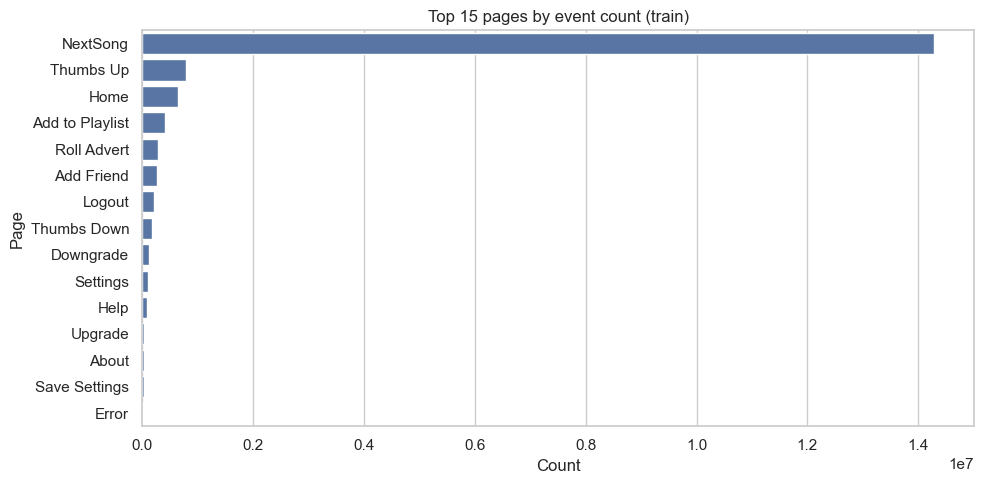

In [20]:
if sns is not None:
    plt.figure(figsize=(10, 5))
    top_pages = train_df['page'].value_counts().head(15)
    sns.barplot(x=top_pages.values, y=top_pages.index)
    plt.title('Top 15 pages by event count (train)')
    plt.xlabel('Count')
    plt.ylabel('Page')
    plt.tight_layout()
    plt.show()
else:
    print('seaborn not installed; run `pip install seaborn` for nicer plots.')

In [21]:
# User-level activity features (light aggregation, just for EDA)
user_activity = (
    train_df
    .groupby('userId')
    .agg(
        n_events=('page', 'size'),
        n_sessions=('sessionId', 'nunique'),
        n_unique_songs=('song', 'nunique'),
        n_unique_artists=('artist', 'nunique'),
        total_length=('length', 'sum'),
    )
)
user_activity.head()

,n_events,n_sessions,n_unique_songs,n_unique_artists,total_length
userId,,,,,
1000025,2005,17,1468,1162,417296.59169
1000035,1556,21,1154,916,310364.86590
1000083,596,11,478,427,122606.27093
1000103,75,3,57,56,13554.73009
1000164,1028,15,778,660,209060.65753


In [22]:
user_activity.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,n_events,n_sessions,n_unique_songs,n_unique_artists,total_length
count,19140.000000,19140.000000,19140.000000,19140.000000,1.914000e+04
mean,914.296552,10.885998,671.018809,535.176123,1.857091e+05
std,1079.652218,10.654959,748.484038,521.360900,2.235359e+05
min,1.000000,1.000000,0.000000,0.000000,0.000000e+00
50%,537.500000,8.000000,412.000000,371.000000,1.064957e+05
75%,1213.000000,14.000000,917.000000,761.000000,2.459463e+05
90%,2245.000000,24.000000,1640.000000,1258.000000,4.597047e+05
95%,3109.050000,32.000000,2217.050000,1618.050000,6.399693e+05
99%,5131.220000,51.000000,3486.610000,2336.000000,1.064980e+06
max,10998.000000,116.000000,6688.000000,3862.000000,2.285957e+06


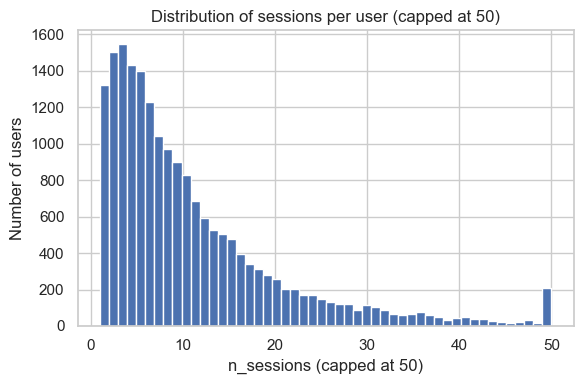

In [23]:
# Example histogram: number of sessions per user (capped at 50 for visibility)
plt.figure(figsize=(6, 4))
user_activity['n_sessions'].clip(upper=50).hist(bins=50)
plt.title('Distribution of sessions per user (capped at 50)')
plt.xlabel('n_sessions (capped at 50)')
plt.ylabel('Number of users')
plt.tight_layout()
plt.show()

In [24]:
# Optional: automated profiling (on sample) using ydata-profiling
# pip install ydata-profiling

try:
    from ydata_profiling import ProfileReport

    sample = train_df.sample(n=min(100_000, len(train_df)), random_state=42)
    profile = ProfileReport(sample, title='Churn Train Sample Profiling', explorative=True)
    profile.to_file('eda_churn_train_profile.html')
    print('Saved profiling report to eda_churn_train_profile.html')
except ImportError:
    print('ydata-profiling not installed. Run: pip install ydata-profiling')
except Exception as e:
    print('Profiling failed:', e)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:01<00:00, 13.00it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Saved profiling report to eda_churn_train_profile.html
